# Local distillation on Auto MPG

`y` = fuel economy (mpg), `X` = 8 vehicle characteristics after encoding
region of manufacture ($n = 392$).  A single fixed train/test split,
Algorithm 1 exactly: one mu-hat, one lambda, local models for the test cars,
then randomized refits and evidence-accumulation clustering.

In [7]:
# ---- setup ------------------------------------------------------------
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import adelie as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mc
from matplotlib.colors import TwoSlopeNorm, ListedColormap
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import AgglomerativeClustering
from tabpfn import TabPFNRegressor

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else (
        "mps" if torch.backends.mps.is_available() else "cpu")
except ImportError:
    DEVICE = "cpu"

REPO = Path("/Users/ercr/Library/CloudStorage/Dropbox-UniversityofMichigan/"
            "Erin Craig/local-distillation-benchmark")
sys.path.insert(0, str(REPO / "benchmark_methods"))
from common import (adelie_lasso_cv, adelie_lasso_predict, local_distill,
                    teacher_similarity, tabpfn_predict)

# ---- experiment configuration ----------------------------------------
SEED      = 0        # fixed seed for the main split
TEST_SIZE = 0.40     
B_DRAWS   = 100      # randomized refits per test point
N_SPLITS  = 20       # replicate splits in Section 2

print(f"device={DEVICE}")

device=mps


In [8]:
#  data: Auto MPG
import pandas as pd
from ucimlrepo import fetch_ucirepo

repo = fetch_ucirepo(id=9)
df = repo.data.features.copy()
df["target"] = repo.data.targets.iloc[:, 0]
df = df.dropna()

feats = [c for c in df.columns if c != "target"]
Xb = df[feats].values.astype(float)
h = int(np.flatnonzero(np.asarray(feats) == "horsepower")[0])
# Xb = np.column_stack([Xb, Xb[:, h] ** 2])
# feats = np.append(feats, "horsepower$^2$")
yb = df["target"].values.astype(float)

combo = np.hstack([Xb, yb[:, None]])           # drop exact duplicate rows
_, uniq = np.unique(combo, axis=0, return_index=True)
uniq.sort()
Xb, yb = Xb[uniq], yb[uniq]
feats = np.array(feats)

# origin is 1 = American, 2 = European, 3 = Japanese
j = int(np.flatnonzero(feats == "origin")[0])
o = Xb[:, j].astype(int)
Xb = np.column_stack([np.delete(Xb, j, axis=1),
                      (o == 2).astype(float), (o == 3).astype(float)])
feats = np.append(np.delete(feats, j), ["origin: European", "origin: Japanese"])
disp = np.array([f.replace("model_year", "model year") for f in feats])

print(f"Auto MPG: n={Xb.shape[0]}, p={Xb.shape[1]}")
print(f"y: mean {yb.mean():.1f}  range [{yb.min():.1f}, {yb.max():.1f}]")
print(list(disp))

Auto MPG: n=392, p=8
y: mean 23.4  range [9.0, 46.6]
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model year', 'origin: European', 'origin: Japanese']


In [9]:
# ---- teacher and randomized local fit ---------------------------------
def teacher_predict(Xtr, ytr, Xte, seed=SEED):
    """TabPFN teacher.  SUPPORT has p = 36, so no feature screen is needed."""
    return tabpfn_predict(Xtr, ytr, Xte)


def local_fit(Xin, yin, xq, tq, S, mu, lam, tau, rng, alpha=1.0, n_draws=0):
    """Augmented weighted elastic net at one query point, whitened form.

    Omega = diag(S_1..S_n, mu/sqrt(n_eff)); randomization is iid N(0, tau^2)
    added to Z = Omega^{1/2} Ybar.  Agrees with local_distill at tau = 0.
    n_draws = 0 returns the unperturbed fit."""
    n_eff = 1.0 / np.sum(S ** 2)
    w = np.concatenate([S, [mu / np.sqrt(n_eff)]])
    s = np.sqrt(w)
    Xa = np.vstack([Xin, xq[None, :]])
    V = np.asfortranarray(np.hstack([s[:, None], s[:, None] * Xa]))
    Z = s * np.concatenate([yin, [tq]])
    pen = np.ones(V.shape[1]); pen[0] = 0.0          # intercept unpenalized

    def fit(Zv):
        st = ad.solver.grpnet(
            V, ad.glm.gaussian(Zv.astype(np.float64)), alpha=alpha,
            lmda_path=np.array([lam / len(Zv)]), intercept=False,
            penalty=pen, progress_bar=False)
        return st.betas[0].toarray().ravel()[1:]

    if n_draws == 0:
        return fit(Z)
    return np.array([fit(Z + rng.normal(0.0, tau, size=len(Z)))
                     for _ in range(n_draws)])

## 1. Fixed split: nuisances, $\hat\mu$, $\lambda$, predictions

In [10]:
# ---- one split: nuisances, mu-hat, lambda, predictions ----------------
t0 = time.perf_counter()

X_tr, X_te, y_tr, y_te = train_test_split(
    Xb, yb, test_size=TEST_SIZE, random_state=SEED)
sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

kf = list(KFold(5, shuffle=True, random_state=SEED).split(X_tr))
t_oof = np.zeros(len(y_tr))
s_oof = np.zeros(len(y_tr))
for a, b in kf:
    t_oof[b] = teacher_predict(X_tr[a], y_tr[a], X_tr[b])
    f = adelie_lasso_cv(X_tr[a], y_tr[a], n_folds=5, seed=SEED)
    s_oof[b] = adelie_lasso_predict(X_tr[b], f["beta"], f["intercept"])

t_te = teacher_predict(X_tr, y_tr, X_te)
gcv  = adelie_lasso_cv(X_tr, y_tr, n_folds=5, seed=SEED)
lam  = float(gcv["best_lambda"])
gbeta = gcv["beta"]
g_te = adelie_lasso_predict(X_te, gbeta, gcv["intercept"])

ld = local_distill(X_tr, y_tr, X_te,
                   teacher_preds_test=t_te, teacher_oof_preds=t_oof,
                   student_oof_preds=s_oof, lambda_=lam,
                   random_state=SEED, lambda_scale="fixed")

print(f"n_train={len(y_tr)}  n_test={len(y_te)}  "
      f"mu-hat={ld['mu']:.3f}  lambda={lam:.5f}  "
      f"({time.perf_counter()-t0:.0f}s)\n")

print(f"{'method':22s}{'test MSE':>10s}{'test R2':>10s}")
preds = {"global lasso (student)": g_te,
         "TabPFN (teacher)":       t_te,
         "local distillation":     ld["predictions"]}
for k, v in preds.items():
    print(f"{k:22s}{mean_squared_error(y_te, v):10.4f}{r2_score(y_te, v):10.3f}")

print(f"\nactive features: global={int((np.abs(gbeta) > 1e-8).sum())}  "
      f"local median={np.median((np.abs(ld['betas']) > 1e-8).sum(1)):.0f}")
print(f"n_eff: median {np.median(ld['n_eff']):.0f} "
      f"[{ld['n_eff'].min():.0f}-{ld['n_eff'].max():.0f}]")

n_train=235  n_test=157  mu-hat=2.030  lambda=0.10827  (5s)

method                  test MSE   test R2
global lasso (student)   10.8072     0.823
TabPFN (teacher)          5.2543     0.914
local distillation        5.5895     0.908

active features: global=6  local median=5
n_eff: median 141 [39-172]


In [11]:
L_student = np.mean((y_tr - s_oof) ** 2)
L_teacher = np.mean((y_tr - t_oof) ** 2)
print(f"CV PSE: student {L_student:.3f}  teacher {L_teacher:.3f}  "
      f"mu-hat = {L_student / L_teacher:.3f}")

CV PSE: student 12.812  teacher 6.311  mu-hat = 2.030


## 2. Choosing the randomization scale $t$

In [12]:
mu  = float(ld["mu"])          # from local_distill in cell 5
sig = (y_tr - t_oof).std()     # teacher OOF residual SD, as in cell 7

# ---- OOF local distillation on a training subset ----------
FRAC_SUB  = 1
GRID_CTAU = [0.01, 0.05, 0.1, 0.25, 0.5, 1, 2, 3, 5, 10]
B_SWEEP   = 100

rng = np.random.default_rng(SEED)
sub = np.sort(rng.choice(len(y_tr), size=int(FRAC_SUB * len(y_tr)),
                         replace=False))
var_phi = t_oof.var()


def local_fit_yhat(Xin, yin, xq, tq, S, mu, lam, tau, rng, n_draws=0):
    """Same augmented whitened fit as local_fit, but returns predictions
    (intercept + xq @ beta) instead of coefficients."""
    n_eff = 1.0 / np.sum(S ** 2)
    w = np.concatenate([S, [mu / np.sqrt(n_eff)]])
    s = np.sqrt(w)
    Xa = np.vstack([Xin, xq[None, :]])
    V = np.asfortranarray(np.hstack([s[:, None], s[:, None] * Xa]))
    Z = s * np.concatenate([yin, [tq]])
    pen = np.ones(V.shape[1]); pen[0] = 0.0

    def fit(Zv):
        st = ad.solver.grpnet(
            V, ad.glm.gaussian(Zv.astype(np.float64)), alpha=1.0,
            lmda_path=np.array([lam / len(Zv)]), intercept=False,
            penalty=pen, progress_bar=False)
        b = st.betas[0].toarray().ravel()
        return float(b[0] + xq @ b[1:])

    if n_draws == 0:
        return fit(Z)
    return np.array([fit(Z + rng.normal(0.0, tau, size=len(Z)))
                     for _ in range(n_draws)])


# per-point OOF weights (self-weight zeroed, renormalized) and n_eff
S_sub = np.zeros((len(sub), len(y_tr)))
for k, j in enumerate(sub):
    d = (t_oof - t_oof[j]) ** 2 / var_phi
    w = np.exp(-d); w[j] = 0.0
    S_sub[k] = w / w.sum()
n_eff_sub = 1.0 / (S_sub ** 2).sum(1)

yhat0 = np.zeros(len(sub))
yhatB = np.zeros((len(GRID_CTAU), B_SWEEP, len(sub)))

t0 = time.perf_counter()
for k, j in enumerate(sub):
    yhat0[k] = local_fit_yhat(X_tr, y_tr, X_tr[j], t_oof[j], S_sub[k],
                              mu, lam, 0.0, rng, n_draws=0)
    for c, ct in enumerate(GRID_CTAU):
        tau = np.sqrt(ct / n_eff_sub[k]) * sig
        yhatB[c, :, k] = local_fit_yhat(X_tr, y_tr, X_tr[j], t_oof[j],
                                        S_sub[k], mu, lam, tau, rng,
                                        n_draws=B_SWEEP)
    if k % 50 == 0:
        el = time.perf_counter() - t0
        print(f"  {k:4d}/{len(sub)}  {el:.0f}s  "
              f"eta {el/(k+1)*(len(sub)-k-1):.0f}s", flush=True)

np.savez_compressed("autompg_ctau_sweep.npz", sub=sub, yhat0=yhat0,
                    yhatB=yhatB, grid=np.array(GRID_CTAU),
                    n_eff_sub=n_eff_sub)

     0/235  0s  eta 76s
    50/235  15s  eta 52s
   100/235  29s  eta 38s
   150/235  43s  eta 24s
   200/235  57s  eta 10s


In [13]:
y_sub = y_tr[sub]
mse0  = np.mean((y_sub - yhat0) ** 2)
mse_m = ((y_sub[None, None, :] - yhatB) ** 2).mean((1, 2))

mse0  = np.median((y_sub - yhat0) ** 2)
mse_m = np.median(((y_sub[None, None, :] - yhatB) ** 2).mean(1), axis=1)

In [14]:
sq = (y_sub[None, None, :] - yhatB) ** 2               # (n_grid, B, n_sub)

NBOOT = 1000
bidx = np.random.default_rng(SEED).integers(0, B_SWEEP, size=(NBOOT, B_SWEEP))
mse_se = np.array([np.median(sq[c][bidx].mean(1), axis=1).std()
                   for c in range(len(GRID_CTAU))])

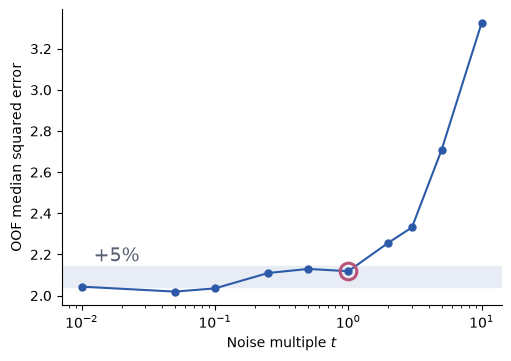

unperturbed 2.042, +5% = 2.144, selected t = 1.0


In [15]:
TOL = 0.05
ok = mse_m <= mse0 * (1 + TOL)
C_STAR = max(np.array(GRID_CTAU)[ok]) if ok.any() else GRID_CTAU[0]

fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")

ax.axhspan(mse0, mse0 * (1 + TOL), color="#e8edf5", zorder=0)
# ax.axhline(mse0, color="#8a94a6", lw=0.8, ls="--", zorder=1)

# ax.errorbar(GRID_CTAU, mse_m, yerr=mse_se, fmt="o-",
#             color="#2d5aa8", ecolor="#a8bcdd", elinewidth=1.2,
#             capsize=3, capthick=1.2, ms=5, zorder=3)
ax.plot([C_STAR], [mse_m[GRID_CTAU.index(C_STAR)]], "o", ms=12,
        mfc="none", mec="#b85478", mew=2.2, zorder=5)
ax.plot(GRID_CTAU, mse_m, "o-", color="#2d5aa8", ms=5, zorder=3)

ax.text(GRID_CTAU[0], mse0 * (1 + TOL), f"  +{TOL:.0%}",
        va="bottom", ha="left", fontsize=14, color="#5a6474")
ax.set_xscale("log")
ax.set_xlabel(r"Noise multiple $t$")
ax.set_ylabel("OOF median squared error")
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("autompg_ctau_mse.pdf", bbox_inches="tight")
plt.show()

print(f"unperturbed {mse0:.3f}, +{TOL:.0%} = {mse0*(1+TOL):.3f}, "
      f"selected t = {C_STAR}")

## 3. Randomized refits

In [16]:
import adelie as ad

B_DRAWS = 100
# ---- randomized refits for every test point ---------------------------
# C_STAR comes from the screen above; see the 'Choosing C_TAU' section.
S    = ld["sim_weights"]
mu   = float(ld["mu"])
sig  = (y_tr - t_oof).std()
phi  = t_te
rng  = np.random.default_rng(SEED)

n_te, p = len(y_te), Xb.shape[1]
beta0 = np.zeros((n_te, p))
betaB = np.zeros((B_DRAWS, n_te, p))

t0 = time.perf_counter()
for i in range(n_te):
    # tau = np.sqrt(C_TAU * S[i].max()) * sig
    tau = np.sqrt(C_STAR / ld["n_eff"][i]) * sig
    beta0[i]    = local_fit(X_tr, y_tr, X_te[i], t_te[i], S[i], mu, lam,
                            tau, rng, n_draws=0)
    betaB[:, i] = local_fit(X_tr, y_tr, X_te[i], t_te[i], S[i], mu, lam,
                            tau, rng, n_draws=B_DRAWS)
    if i % 250 == 0:
        el = time.perf_counter() - t0
        print(f"  {i:5d}/{n_te}  nnz={(np.abs(beta0[i]) > 1e-8).sum():3d}  "
              f"tau={tau:.4f}  {el:.0f}s  eta {el/(i+1)*(n_te-i-1):.0f}s",
              flush=True)

np.savez_compressed("support_local_betas.npz",
                    beta0=beta0, betaB=betaB, phi=phi, feats=feats)

PI  = (np.abs(betaB) > 1e-8).mean(0)
nnz = (np.abs(beta0) > 1e-8).sum(1)
stable = np.array([(PI[i][np.abs(beta0[i]) > 1e-8] > 0.9).mean()
                   for i in range(n_te)])
print(f"\nnnz median {np.median(nnz):.0f} [{nnz.min()}-{nnz.max()}]   "
      f"stable fraction (pi>0.9) {stable.mean():.2f}")

      0/157  nnz=  5  tau=0.2149  0s  eta 11s

nnz median 5 [5-8]   stable fraction (pi>0.9) 0.71


## 4. Clustering

2 0.498 [87 70]
3 0.616 [68 69 20]
4 0.523 [39 67 19 32]
5 0.527 [67 31  6 39 14]
6 0.488 [14 33 31  6 36 37]
7 0.459 [36 29 14 12  6 33 27]
8 0.429 [21 30  6 13 26 32 13 16]
9 0.448 [23 33  3 36  4  6 12 22 18]
10 0.417 [ 4 12 32 13 22 12 20  3 26 13]
11 0.425 [22 32 12 18 22  3  1 23  6 15  3]

selected K = 3


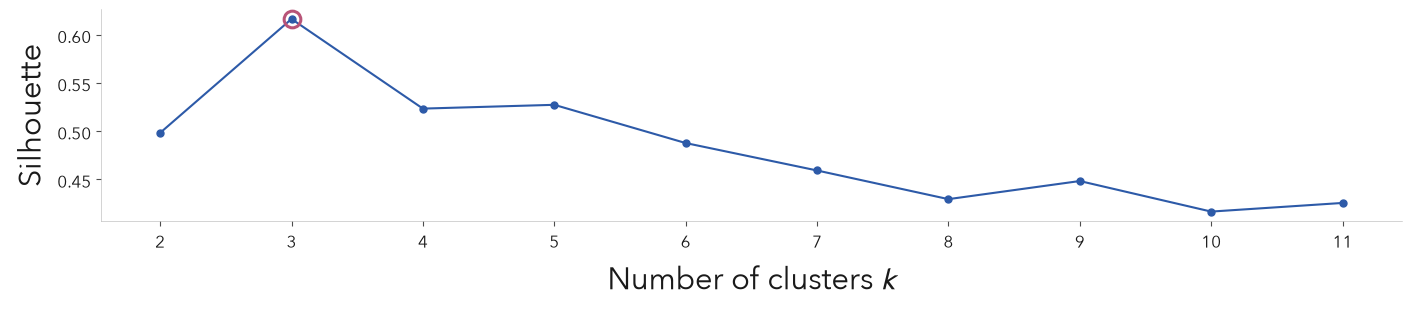

In [17]:
# ---- silhouette / elbow plot ------------------------------------------
from sklearn.cluster import KMeans

ks, scores = list(range(2, 12)), []
for k in ks:
    l0 = KMeans(k, n_init=10, random_state=SEED).fit_predict(beta0)
    scores.append(silhouette_score(beta0, l0))
    print(k, round(scores[-1], 3), np.bincount(l0))

K = ks[int(np.argmax(scores))]
print(f"\nselected K = {K}")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Avenir Next", "Avenir", "Helvetica Neue", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "font.size": 14, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "xtick.labelcolor": "#1a1a1a", "ytick.labelcolor": "#1a1a1a",
    "axes.labelcolor": "#1a1a1a", "text.color": "#1a1a1a",
    "axes.edgecolor": "#b3b3b3", "axes.linewidth": 0.4,
    "xtick.color": "#4d4d4d", "ytick.color": "#4d4d4d",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

fig, ax = plt.subplots(figsize=(14, 3), layout="constrained")

ax.plot(ks, scores, "o-", color="#2d5aa8", ms=5, zorder=3)
ax.plot([K], [max(scores)], "o", ms=12,
        mfc="none", mec="#b85478", mew=2.2, zorder=5)

ax.set_xlabel("Number of clusters $k$", fontsize=22)
ax.set_ylabel("Silhouette", fontsize=22)
ax.set_xticks(ks)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("autompg_silhouette.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

cluster sizes: [69, 68, 20]


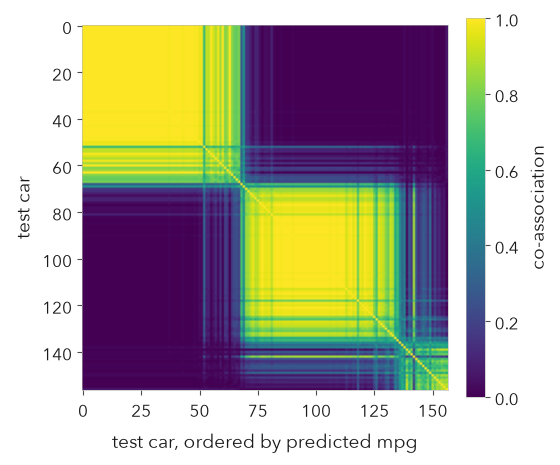

In [18]:
K = 3
o = np.argsort(phi)

# ---- evidence-accumulation clustering ---------------------------------
co = np.zeros((n_te, n_te))
for b in range(B_DRAWS):
    l = KMeans(K, n_init=10, random_state=SEED + b).fit_predict(betaB[b])
    co += (l[:, None] == l[None, :])
co /= B_DRAWS
lab = AgglomerativeClustering(n_clusters=K, metric="precomputed",
                              linkage="average").fit_predict(1 - co)
rows_c = np.argsort([phi[lab == c].mean() for c in range(K)])
print("cluster sizes:", [int(np.sum(lab == c)) for c in rows_c])

fig, ax = plt.subplots(figsize=(5.5, 4.6), layout="constrained")
im = ax.imshow(co[np.ix_(o, o)], cmap="viridis", vmin=0, vmax=1)
ax.set_xlabel("test car, ordered by predicted mpg")
ax.set_ylabel("test car")
fig.colorbar(im, ax=ax, label="co-association")
plt.savefig("autompg_coassociation.pdf", bbox_inches="tight")
plt.show()

### Figures

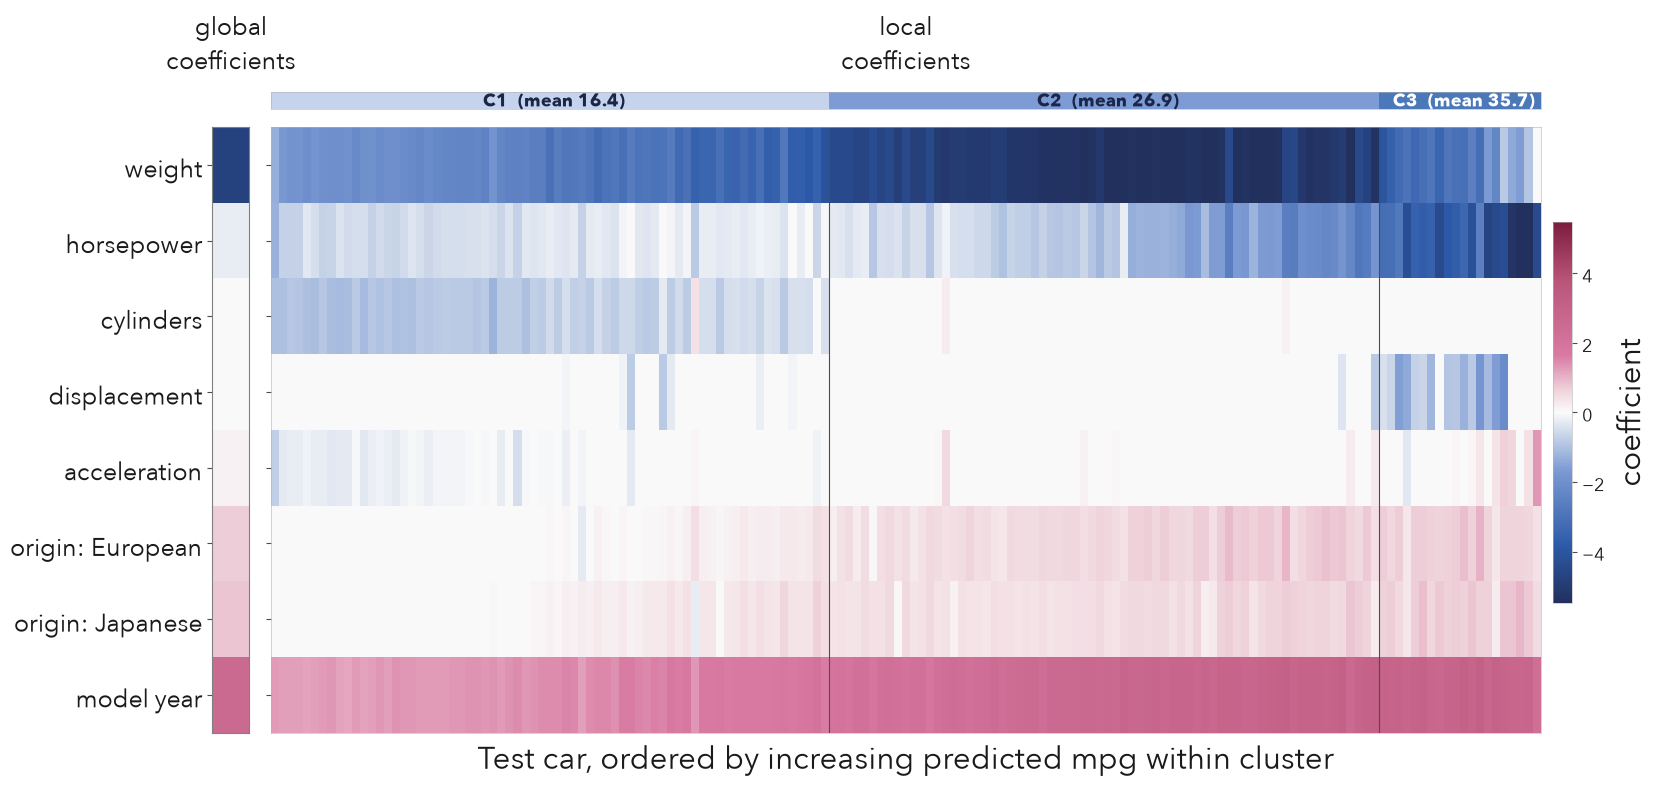

In [19]:
import matplotlib.colors as mc
LD_DIVERGING = mc.LinearSegmentedColormap.from_list("ld_div", [
    (0.00, "#22305e"),   # deep ultramarine
    (0.15, "#2d5aa8"),   # TabPFN blue
    (0.35, "#7d9bd4"),   # light blue
    (0.44, "#c8d5e8"),
    (0.50, "#fbfbfb"),   # zero -> near-white
    (0.56, "#efd2da"),
    (0.65, "#d97aa3"),   # light rose
    (0.85, "#b85478"),   # mid wine-rose
    (1.00, "#7d1c3f"),   # deep wine
], N=256)

CLUSTER_COLS = ["#c5d3ec", "#7d9bd4", "#4a78b8", "#2d5aa8"]

# ---- clustered coefficient heatmap (all features, matches intro) -------
act = np.abs(beta0).max(0) > 1e-8
Bm, gidx = beta0[:, act], np.flatnonzero(act)

order_g = np.lexsort((Bm[np.argsort(phi)].mean(0), gbeta[gidx]))  # same rows as intro

ord_pt = np.concatenate([np.flatnonzero(lab == c)[np.argsort(phi[lab == c])]
                         for c in rows_c])
sizes = [int(np.sum(lab == c)) for c in rows_c]
bounds = np.cumsum(sizes)[:-1]

M = Bm[np.ix_(ord_pt, order_g)].T
G = gbeta[gidx[order_g]][:, None]
v = np.quantile(np.abs(M), 0.99)
norm = TwoSlopeNorm(0, -v, v)
strip = np.concatenate([np.full(s, k) for k, s in enumerate(sizes)])[None, :]

fig, ax = plt.subplots(2, 2, figsize=(16.5, 7), sharey="row", sharex="col",
                       layout="constrained",
                       gridspec_kw={"width_ratios": [1, 34],
                                    "height_ratios": [1, 36],
                                    "wspace": 0.02, "hspace": 0.04})
ax[0, 0].axis("off")

ax[0, 1].imshow(strip, aspect="auto", interpolation="nearest",
                cmap=ListedColormap(CLUSTER_COLS[:K]), vmin=0, vmax=K - 1)
ax[0, 1].set_yticks([]); ax[0, 1].set_xticks([]); ax[0, 1].tick_params(left=False)
lo = 0
for k, s in enumerate(sizes):
    mphi = phi[ord_pt][lo:lo + s].mean()
    ax[0, 1].text(lo + s / 2, 0, f"C{k+1}  (mean {mphi:.1f})",
                  ha="center", va="center", fontsize=13, weight="bold",
                  color="white" if k >= 2 else "#1a2547")
    lo += s

ax[1, 0].imshow(G, cmap=LD_DIVERGING, norm=norm, aspect="auto",
                interpolation="nearest")
ax[1, 0].set_xticks([])
ax[1, 0].set_yticks(range(len(order_g)))
ax[1, 0].set_yticklabels([disp[gidx[j]] for j in order_g],
                         fontsize=18, color="#1a1a1a")
for sp in ax[1, 0].spines.values():
    sp.set_color("#808080"); sp.set_linewidth(0.8)

im = ax[1, 1].imshow(M, cmap=LD_DIVERGING, norm=norm, aspect="auto",
                     interpolation="nearest")
for b in bounds:
    ax[1, 1].axvline(b - 0.5, color="#4d4d4d", lw=0.8)
ax[1, 1].set_xticks([])
ax[1, 1].set_xlabel("Test car, ordered by increasing predicted mpg within cluster",
                    fontsize=22)
cb = fig.colorbar(im, ax=ax[:, 1], fraction=0.015, pad=0.01)
cb.set_label("coefficient", fontsize=22)
cb.ax.tick_params(labelsize=13, labelcolor="#1a1a1a")
cb.outline.set_linewidth(0.4); cb.outline.set_edgecolor("#b3b3b3")

# headers above the cluster strip, placed in figure coordinates so they sit
# level with each other (must come after constrained_layout has run)
fig.canvas.draw()
p0, p1 = ax[0, 0].get_position(), ax[0, 1].get_position()
fig.text(p0.x0 + p0.width / 2, p1.y1 + 0.02, "global\ncoefficients",
         ha="center", va="bottom", fontsize=18, color="#1a1a1a")
fig.text(p1.x0 + p1.width / 2, p1.y1 + 0.02, "local\ncoefficients",
         ha="center", va="bottom", fontsize=18, color="#1a1a1a")

plt.savefig("autompg_local_coefs.pdf", bbox_inches="tight")
plt.show()

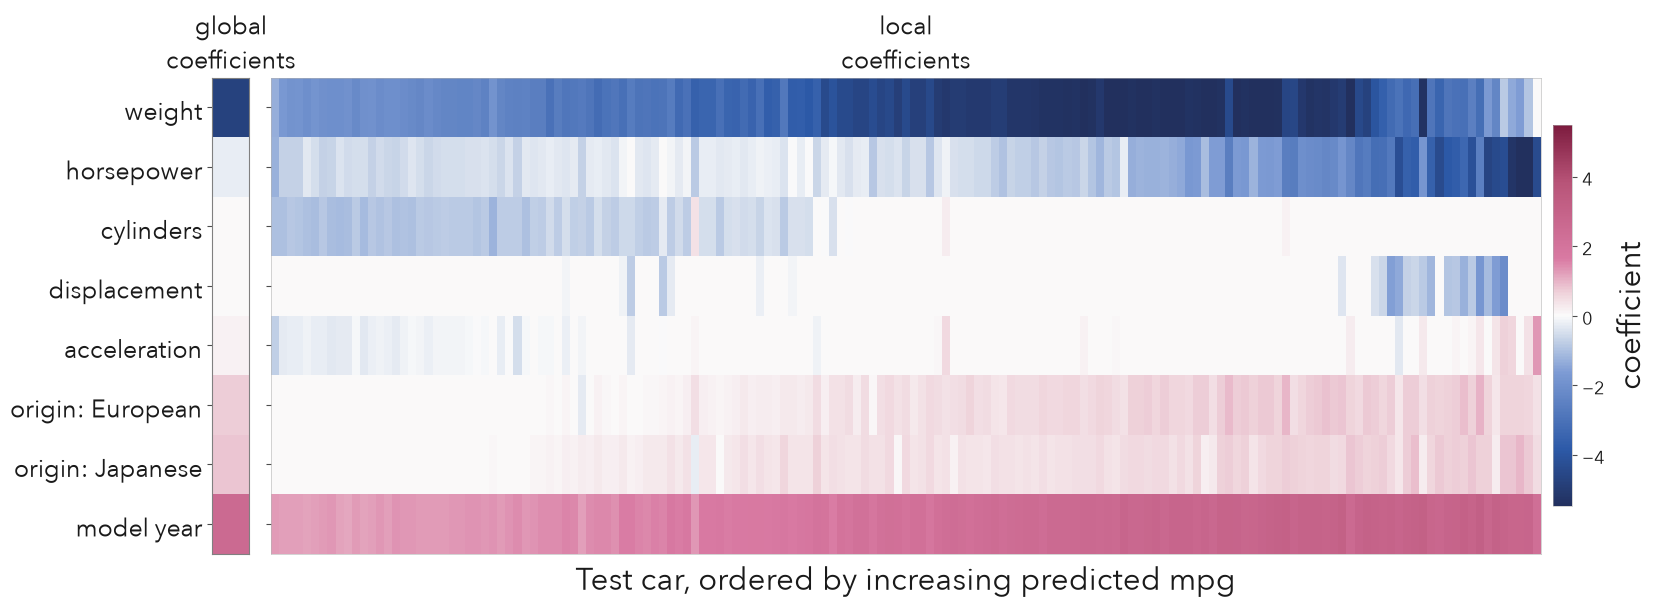

In [20]:
# ---- coefficient heatmap, ordered by predicted mpg (no clustering) -----
act = np.abs(beta0).max(0) > 1e-8
Bm, gidx = beta0[:, act], np.flatnonzero(act)

ord_pt = np.argsort(phi)
order_g = np.lexsort((Bm[ord_pt].mean(0), gbeta[gidx]))

M = Bm[np.ix_(ord_pt, order_g)].T
G = gbeta[gidx[order_g]][:, None]
v = np.quantile(np.abs(M), 0.99)
norm = TwoSlopeNorm(0, -v, v)

fig, ax = plt.subplots(1, 2, figsize=(16.5, 6), sharey=True,
                       layout="constrained",
                       gridspec_kw={"width_ratios": [1, 34], "wspace": 0.02})

ax[0].imshow(G, cmap=LD_DIVERGING, norm=norm, aspect="auto",
             interpolation="nearest")
ax[0].set_xticks([]); ax[0].set_title("global\ncoefficients", fontsize=18, pad=4)
ax[0].set_yticks(range(len(order_g)))
ax[0].set_yticklabels([disp[gidx[j]] for j in order_g],
                      fontsize=18, color="#1a1a1a")
for sp in ax[0].spines.values():
    sp.set_color("#808080"); sp.set_linewidth(0.8)

im = ax[1].imshow(M, cmap=LD_DIVERGING, norm=norm, aspect="auto",
                  interpolation="nearest")
ax[1].set_title("local\ncoefficients", fontsize=18, pad=4)
ax[1].set_xticks([])
ax[1].set_xlabel("Test car, ordered by increasing predicted mpg", fontsize=22)
cb = fig.colorbar(im, ax=ax[1], fraction=0.015, pad=0.01)
cb.set_label("coefficient", fontsize=22)
cb.ax.tick_params(labelsize=13, labelcolor="#1a1a1a")
cb.outline.set_linewidth(0.4); cb.outline.set_edgecolor("#b3b3b3")

plt.savefig("autompg_intro_local_coefs.pdf", bbox_inches="tight")
plt.show()

## 5. Tables and diagnostics

In [21]:
i = 85
nz = np.flatnonzero(np.abs(beta0[i]) > 1e-8)
# nz = nz[np.argsort(-np.abs(beta0[i, nz]))]
nz = nz[np.lexsort((-np.abs(beta0[i, nz]), -np.round(PI[i, nz], 2)))]
show = [j for j in nz if abs(beta0[i, j]) > 0.015]
half = (len(show) + 1) // 2
pad = show + [None] * half
for a, b in zip(pad[:half], pad[half:2*half]):
    l = f"{disp[a]} & ${beta0[i,a]:.2f}$ & {PI[i,a]:.0%} "
    r = (f"& {disp[b]} & ${beta0[i,b]:.2f}$ & {PI[i,b]:.0%}"
         if b is not None else "& & & ")
    print(l + r + r"\\")
print(f"% {len(show)} shown of {len(nz)} active, "
      f"{(PI[i][nz] > 0.9).sum()} above 90%")

weight & $-5.11$ & 100% & origin: Japanese & $0.41$ & 98%\\
model year & $2.28$ & 100% & cylinders & $0.24$ & 75%\\
acceleration & $0.52$ & 99% & horsepower & $-0.17$ & 70%\\
origin: European & $0.40$ & 99% & & & \\
% 7 shown of 7 active, 5 above 90%


In [22]:
err = np.abs(phi - y_te)
cand = [(i, err[i], (np.abs(beta0[i]) > 1e-8).sum(),
         ((PI[i] < 0.9) & (np.abs(beta0[i]) > 1e-8)).sum())
        for i in range(n_te)]
cand = [c for c in cand if c[2] >= 6 and c[3] >= 2]   # ≥6 active, ≥2 uncertain
cand.sort(key=lambda c: c[1])
for i, e, nz, un in cand[:8]:
    print(f"car {i:3d}  pred {phi[i]:5.1f}  obs {y_te[i]:5.1f}  "
          f"err {e:4.1f}  nnz {nz}  unstable {un}")

car 113  pred  19.2  obs  19.2  err  0.0  nnz 6  unstable 4
car  85  pred  23.7  obs  23.9  err  0.2  nnz 7  unstable 2
car 152  pred  18.2  obs  18.0  err  0.2  nnz 6  unstable 4
car  65  pred  16.2  obs  16.0  err  0.2  nnz 7  unstable 5
car   8  pred  19.8  obs  20.0  err  0.2  nnz 6  unstable 4
car 132  pred  23.3  obs  23.0  err  0.3  nnz 6  unstable 2
car  50  pred  26.4  obs  26.0  err  0.4  nnz 6  unstable 2
car  21  pred  16.4  obs  16.0  err  0.4  nnz 8  unstable 6


In [23]:
for j, name in enumerate(disp):
    print(f"{name:20s} mean pi {PI[:, j].mean():.2f}   "
          f"pi>0.9 in {(PI[:, j] > 0.9).mean():.0%} of cars")

displacement         mean pi 0.26   pi>0.9 in 0% of cars
cylinders            mean pi 0.49   pi>0.9 in 22% of cars
horsepower           mean pi 0.87   pi>0.9 in 54% of cars
weight               mean pi 0.99   pi>0.9 in 97% of cars
acceleration         mean pi 0.54   pi>0.9 in 4% of cars
model year           mean pi 1.00   pi>0.9 in 100% of cars
origin: European     mean pi 0.81   pi>0.9 in 57% of cars
origin: Japanese     mean pi 0.81   pi>0.9 in 57% of cars


In [24]:
cl = int(np.flatnonzero(disp == "cylinders")[0])
lo, hi = phi < np.quantile(phi, 0.33), phi > np.quantile(phi, 0.67)
import collections
print("low-mpg cylinders:", collections.Counter(np.round(X_te[lo, cl] * sc.scale_[cl] + sc.mean_[cl]).astype(int)))
print("high-mpg cylinders:", collections.Counter(np.round(X_te[hi, cl] * sc.scale_[cl] + sc.mean_[cl]).astype(int)))

low-mpg cylinders: Counter({8: 39, 6: 13})
high-mpg cylinders: Counter({4: 51, 6: 1})


In [25]:
lo = phi < np.quantile(phi, 1/3)
hi = phi > np.quantile(phi, 2/3)
print(f"low-mpg  n={lo.sum():3d}  mean y {y_te[lo].mean():5.1f}  sd {y_te[lo].std():.2f}")
print(f"high-mpg n={hi.sum():3d}  mean y {y_te[hi].mean():5.1f}  sd {y_te[hi].std():.2f}")

low-mpg  n= 52  mean y  15.2  sd 2.29
high-mpg n= 52  mean y  32.2  sd 4.84


In [26]:
for f in ("cylinders", "displacement"):
    j = int(np.flatnonzero(np.array(disp) == f)[0])
    print(f"{f:14s} global beta {gbeta[j]:+.4f}")

cylinders      global beta +0.0000
displacement   global beta +0.0000


In [27]:
# ---- M4 check: does the clustering beat quantile bins of phi? ----------
from sklearn.metrics import adjusted_rand_score

# (a) the trivial alternative: K equal-mass bins of predicted mpg
qbin = np.digitize(phi, np.quantile(phi, np.arange(1, K) / K))

ari = adjusted_rand_score(lab, qbin)
print(f"ARI(clusters, quantile bins) = {ari:.3f}   "
      f"(1 = identical partitions, ~0 = unrelated)")

# (b) contiguity: is each cluster an interval of the prediction axis?
#     fraction of members inside the cluster's own [min, max] phi-range
#     that actually belong to it (1.0 = perfectly contiguous)
for rank, c in enumerate(rows_c):
    in_range = (phi >= phi[lab == c].min()) & (phi <= phi[lab == c].max())
    frac = (lab[in_range] == c).mean()
    print(f"cluster C{rank+1}: size {np.sum(lab == c):3d}  "
          f"phi range [{phi[lab == c].min():.1f}, {phi[lab == c].max():.1f}]  "
          f"contiguity {frac:.2f}")

# (c) confusion matrix, clusters (rows, ordered by mean phi) vs bins
conf = np.array([[np.sum((lab == c) & (qbin == b)) for b in range(K)]
                 for c in rows_c])
print("\ncluster x bin counts:\n", conf)

# (d) do the group-mean coefficients differ where a reader would care?
mc = np.array([beta0[lab == c].mean(0) for c in rows_c])     # cluster means
mb = np.array([beta0[qbin == b].mean(0) for b in range(K)])  # bin means
d = np.abs(mc - mb)
scale = np.abs(beta0).mean()
print(f"\nmax |cluster-mean - bin-mean| coef: {d.max():.3f} "
      f"(mean |beta| = {scale:.3f})")
for j in np.argsort(-d.max(0))[:4]:
    print(f"  {disp[j]:15s} cluster means {np.round(mc[:, j], 2)}  "
          f"bin means {np.round(mb[:, j], 2)}")

ARI(clusters, quantile bins) = 0.420   (1 = identical partitions, ~0 = unrelated)
cluster C1: size  69  phi range [10.6, 21.7]  contiguity 0.99
cluster C2: size  68  phi range [21.4, 34.5]  contiguity 0.91
cluster C3: size  20  phi range [33.4, 41.4]  contiguity 0.95

cluster x bin counts:
 [[52 17  0]
 [ 0 35 33]
 [ 0  0 20]]

max |cluster-mean - bin-mean| coef: 1.742 (mean |beta| = 1.033)
  weight          cluster means [-2.67 -5.12 -2.5 ]  bin means [-2.41 -4.47 -4.24]
  horsepower      cluster means [-0.4  -1.17 -4.06]  bin means [-0.45 -0.51 -2.62]
  displacement    cluster means [-0.04 -0.02 -0.85]  bin means [-0.04 -0.01 -0.34]
  model year      cluster means [1.44 2.54 2.84]  bin means [1.36 2.08 2.83]
